# Exploratory Data Analysis — ISIC 2018 Task 3

**Dataset:** ISIC 2018 Challenge — Task 3: Lesion Diagnosis
**Goal:** Multi-class classification of dermoscopic images into 7 skin lesion categories.

This notebook explores the dataset before any modeling. It covers:

1. Setup and path verification
2. Loading the ground-truth labels
3. Class distribution (the central challenge of this dataset is **class imbalance**)
4. Consistency check between CSV entries and image files
5. Sample images per class
6. Image dimensions and properties



## 1. Setup

We start by importing libraries and defining paths to the dataset, relative to the project root so the notebook is portable across machines.

In [5]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Project paths
PROJECT_ROOT = Path.cwd().parent        
DATA_RAW = PROJECT_ROOT / "data" / "raw"
IMAGES_DIR = DATA_RAW / "ISIC2018_Task3_Training_Input"
LABELS_CSV = DATA_RAW / "ISIC2018_Task3_Training_GroundTruth" / "ISIC2018_Task3_Training_GroundTruth.csv"
print("Project root :", PROJECT_ROOT)
print("Images dir   :", IMAGES_DIR)
print("Labels CSV   :", LABELS_CSV)
print()
print("Images dir exists?", IMAGES_DIR.exists())
print("Labels CSV exists?", LABELS_CSV.exists())

Project root : c:\Users\asus\Documents\skin cancer
Images dir   : c:\Users\asus\Documents\skin cancer\data\raw\ISIC2018_Task3_Training_Input
Labels CSV   : c:\Users\asus\Documents\skin cancer\data\raw\ISIC2018_Task3_Training_GroundTruth\ISIC2018_Task3_Training_GroundTruth.csv

Images dir exists? True
Labels CSV exists? True


## 2. Load the ground-truth labels

The labels CSV maps each image (by ID) to one of 7 disease classes via a **one-hot encoding** — each row has a 1 in exactly one of the 7 class columns.

The 7 classes are:

| Code | Full name | Description |
|------|-----------|-------------|
| **MEL** | Melanoma | Malignant — the most dangerous form of skin cancer |
| **NV**  | Melanocytic nevus | Common mole — benign |
| **BCC** | Basal cell carcinoma | Malignant — most common skin cancer, low metastasis |
| **AKIEC** | Actinic keratoses / intraepithelial carcinoma | Pre-cancerous / early-stage malignant |
| **BKL** | Benign keratosis-like lesion | Benign |
| **DF**  | Dermatofibroma | Benign |
| **VASC** | Vascular lesion | Benign — angiomas, hemorrhages, etc. |

We expect roughly 10,015 rows.

In [6]:
# Load the labels CSV
df = pd.read_csv(LABELS_CSV)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print("First 5 rows:")
df.head()

Shape: (10015, 8)
Columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

First 5 rows:


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Class distribution

This is the **most important EDA step** for our project. Skin lesion datasets are notoriously imbalanced because rare diseases are, by definition, rare. The imbalance directly motivates our use of generative augmentation: under-represented classes hurt model performance, especially for the malignant classes that matter most clinically (e.g., melanoma).

We compute:
- The count of images per class
- The percentage of the dataset each class represents
- The **imbalance ratio**: largest class / smallest class

In [8]:
# Class names in the order they appear in the CSV
CLASSES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# Count per class (sum of the one-hot column = number of images of that class)
class_counts = df[CLASSES].sum().astype(int)
class_pct = (class_counts / len(df) * 100).round(2)

# Combine into one table
summary = pd.DataFrame({
    'count': class_counts,
    'percent': class_pct
}).sort_values('count', ascending=False)

print("Class distribution (sorted by count):")
print(summary)
print()
print(f"Total images: {class_counts.sum()}")
print(f"Largest class : {summary.index[0]}  ({summary['count'].iloc[0]} images)")
print(f"Smallest class: {summary.index[-1]}  ({summary['count'].iloc[-1]} images)")
print(f"Imbalance ratio (largest / smallest): {summary['count'].iloc[0] / summary['count'].iloc[-1]:.1f}x")

Class distribution (sorted by count):
       count  percent
NV      6705    66.95
MEL     1113    11.11
BKL     1099    10.97
BCC      514     5.13
AKIEC    327     3.27
VASC     142     1.42
DF       115     1.15

Total images: 10015
Largest class : NV  (6705 images)
Smallest class: DF  (115 images)
Imbalance ratio (largest / smallest): 58.3x


### 3.1 Visualizing the class distribution

A bar chart makes the imbalance immediately visible — NV dominates, and the four smallest classes are barely visible relative to it.

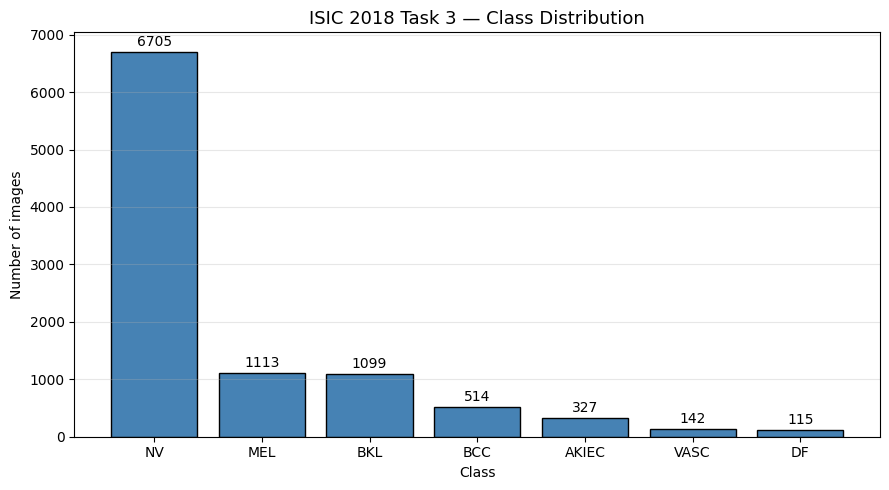

Saved figure to results/class_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(summary.index, summary['count'], color='steelblue', edgecolor='black')

# Annotate each bar with its count
for bar, count in zip(bars, summary['count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            str(count),
            ha='center', va='bottom', fontsize=10)

ax.set_title('ISIC 2018 Task 3 — Class Distribution', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved figure to results/class_distribution.png")

**Figure 1** Class distribution of the ISIC 2018 Task 3 training set. NV (benign melanocytic nevus) accounts for ~67% of all samples, while DF and VASC each represent less than 1.5%. The imbalance ratio of 58.3× motivates the use of generative augmentation in this work.

## 4. Filename consistency check

Before using the data, we verify:

1. Every image ID listed in the CSV has a corresponding `.jpg` file on disk.
2. No "orphan" images exist on disk without a matching CSV row.

A mismatch here would cause silent bugs during training (e.g., `FileNotFoundError` mid-epoch), so we catch it now.

In [10]:
# All image IDs from the CSV
csv_ids = set(df['image'].tolist())

# All image IDs found on disk (file stem = filename without extension)
disk_ids = set(p.stem for p in IMAGES_DIR.glob("*.jpg"))

# Cross-check
in_csv_only  = csv_ids - disk_ids   # in CSV but no file on disk
on_disk_only = disk_ids - csv_ids   # file on disk but not in CSV

print(f"CSV entries          : {len(csv_ids)}")
print(f"Image files on disk  : {len(disk_ids)}")
print(f"Missing on disk      : {len(in_csv_only)}")
print(f"Orphan files on disk : {len(on_disk_only)}")

if len(in_csv_only) == 0 and len(on_disk_only) == 0:
    print("\nPerfect match — every CSV row has its image, and no orphan files exist.")
else:
    print("\n Mismatch detected!")
    if in_csv_only:
        print("  Examples of CSV entries without an image file:", list(in_csv_only)[:5])
    if on_disk_only:
        print("  Examples of orphan image files:", list(on_disk_only)[:5])

CSV entries          : 10015
Image files on disk  : 10015
Missing on disk      : 0
Orphan files on disk : 0

Perfect match — every CSV row has its image, and no orphan files exist.


## 5. Sample images per class

We display 4 random examples from each of the 7 classes. This helps build intuition for:

- What each class looks like visually
- Inter-class similarity (e.g., MEL vs NV can be visually confusable — that's why this problem is hard)
- Common image-quality artifacts: dark corners (vignetting), hair, rulers, ink markings, color stickers

We use a fixed random seed for reproducibility.

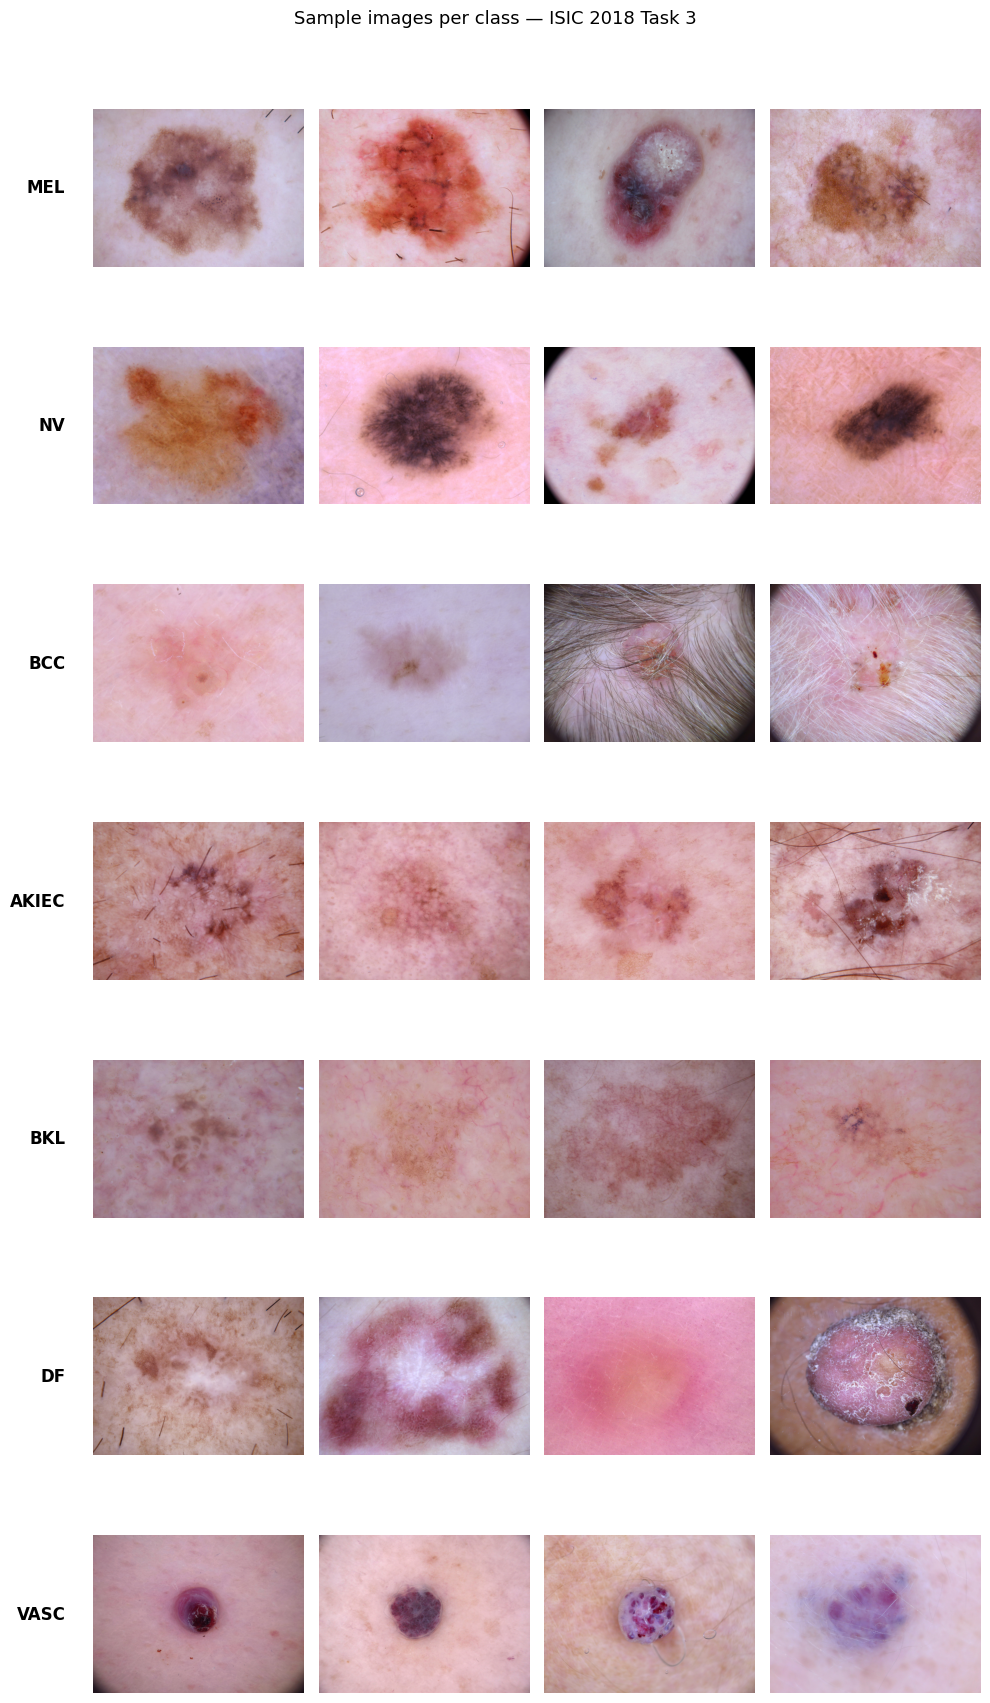

Saved figure to results/sample_per_class.png


In [11]:
# Reproducibility
rng = np.random.default_rng(seed=42)

# Convert one-hot back to a single label column for easier filtering
df['label'] = df[CLASSES].idxmax(axis=1)

N_PER_CLASS = 4
fig, axes = plt.subplots(len(CLASSES), N_PER_CLASS, figsize=(N_PER_CLASS * 2.5, len(CLASSES) * 2.5))

for row, cls in enumerate(CLASSES):
    # Random sample of N image IDs from this class
    cls_ids = df.loc[df['label'] == cls, 'image'].tolist()
    sample_ids = rng.choice(cls_ids, size=N_PER_CLASS, replace=False)

    for col, img_id in enumerate(sample_ids):
        img = Image.open(IMAGES_DIR / f"{img_id}.jpg")
        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, rotation=0, ha='right', va='center',
                          fontsize=12, fontweight='bold', labelpad=20)
            # We turned axis off but want to keep ylabel — restore the y-axis bits
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle('Sample images per class — ISIC 2018 Task 3', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'sample_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved figure to results/sample_per_class.png")

**Figure 2:** Random samples of 4 images per class from the ISIC 2018 Task 3 training set, drawn with a fixed seed for reproducibility.

### Observations

Several patterns are visible in the samples that have direct implications for modeling:

- **Inter-class visual similarity is high.** MEL (malignant melanoma) and NV (benign nevus) both appear as dark pigmented lesions; AKIEC and BKL appear as flat, pink-tan keratotic patches. These are the same confusions clinicians struggle with, and we should expect the model to confuse them as well.

- **Imaging artifacts are common.** Several samples show hair occlusion (BCC, AKIEC rows), dark vignetting from the dermatoscope (DF row 4), and color/skin-tone variation across patients. These are *real-world* artifacts that the model must learn to ignore — or, if they correlate with class for spurious reasons, that we must explicitly address.

- **VASC is visually distinct.** Vascular lesions are clearly red/purple and structurally different from pigmented or keratotic lesions. We expect this class to be one of the easiest to classify *individually*, but because only 142 images are available, the model may still struggle with it due to data scarcity rather than visual difficulty.

- **Backgrounds and framing are inconsistent.** Some lesions fill the frame; others occupy a small fraction of the image. Center cropping or aggressive resizing risks discarding diagnostic information.

These observations directly motivate our preprocessing and augmentation choices in the following sections: standardized resizing to a fixed input, ImageNet-style normalization, and geometric augmentations (flips, rotations) that are clinically valid (a skin lesion has no canonical orientation).

## 6. Image dimensions and properties

Before designing preprocessing, we check whether images share a common size or vary. This affects:

- **Resize target** for the model input (a smaller, fixed size like 224×224 keeps GPU memory predictable)
- **Aspect ratios** — if most images share one aspect ratio, simple resize is fine; if not, we need padding or cropping logic
- **File sizes** — affects data-loading speed (we may pre-resize to disk if disk I/O becomes a bottleneck)

We sample 500 images for speed (checking all 10,015 would take a few minutes; 500 is more than enough to characterize the distribution).

In [12]:
# Sample 500 random images to characterize dimensions (fast enough)
sample_ids = rng.choice(df['image'].tolist(), size=500, replace=False)

widths, heights, file_sizes_kb = [], [], []
for img_id in sample_ids:
    path = IMAGES_DIR / f"{img_id}.jpg"
    with Image.open(path) as img:
        widths.append(img.width)
        heights.append(img.height)
    file_sizes_kb.append(path.stat().st_size / 1024)

widths = np.array(widths)
heights = np.array(heights)
file_sizes_kb = np.array(file_sizes_kb)
aspect_ratios = widths / heights

print("Image dimensions (sampled from 500 images):")
print(f"  Width  : min={widths.min()}, max={widths.max()}, median={int(np.median(widths))}")
print(f"  Height : min={heights.min()}, max={heights.max()}, median={int(np.median(heights))}")
print(f"  Aspect : min={aspect_ratios.min():.3f}, max={aspect_ratios.max():.3f}, median={np.median(aspect_ratios):.3f}")
print(f"  File   : min={file_sizes_kb.min():.0f} KB, max={file_sizes_kb.max():.0f} KB, median={np.median(file_sizes_kb):.0f} KB")
print()

# How many unique sizes are there?
unique_sizes = set(zip(widths.tolist(), heights.tolist()))
print(f"Number of unique (width, height) combos in sample: {len(unique_sizes)}")
if len(unique_sizes) <= 5:
    print("Sizes:", unique_sizes)

Image dimensions (sampled from 500 images):
  Width  : min=600, max=600, median=600
  Height : min=450, max=450, median=450
  Aspect : min=1.333, max=1.333, median=1.333
  File   : min=118 KB, max=437 KB, median=271 KB

Number of unique (width, height) combos in sample: 1
Sizes: {(600, 450)}


### Observations

All 500 sampled images share identical dimensions: **600 × 450 pixels** (4:3 aspect ratio). This is consistent with the ISIC 2018 challenge's standardized release format and greatly simplifies preprocessing — no padding, no aspect-ratio handling, no edge cases.

File sizes range from 118 KB to 437 KB (median 271 KB), so the full training set (~10,015 images × ~270 KB ≈ 2.6 GB) fits comfortably in RAM if needed, though we will use a DataLoader to stream from disk in batches.

### Preprocessing implications

Based on this analysis, we will:

- **Resize to 224 × 224** for model input (standard size for ImageNet-pretrained backbones we plan to use as baselines; preserves enough detail for lesion classification while keeping GPU memory bounded).
- **Normalize** with ImageNet mean/std since we will fine-tune pretrained models.
- Apply **geometric augmentations** (horizontal/vertical flip, rotation ±30°) only on the training set — skin lesions have no canonical orientation.
- Apply **mild color jitter** to handle skin-tone and lighting variation, but not so much that we destroy diagnostic color information.

## 7. EDA Summary

**Dataset:** ISIC 2018 Challenge, Task 3 (Lesion Diagnosis) — 10,015 dermoscopic images, 7 disease classes.

**Key findings:**

1. **Severe class imbalance** — NV (benign nevus) constitutes 67% of the dataset, while DF and VASC each represent <1.5%. Imbalance ratio: **58.3×** (largest:smallest).

2. **Clean dataset** — every CSV entry has a matching image file; no orphans on disk.

3. **Uniform image size** — all images are 600×450 pixels (4:3 aspect ratio), simplifying preprocessing.

4. **High inter-class visual similarity** — particularly between MEL/NV and AKIEC/BKL; expected confusion in the confusion matrix.

5. **Common imaging artifacts** — hair, vignetting, color casts, ink markings; the model must learn to be invariant to these.

**Implications for the project:**

- **Accuracy is misleading** as a primary metric (a trivial "always NV" predictor scores 67%). We will report **macro F1**, **balanced accuracy**, and **per-class recall**, especially for the malignant minority classes.
- **Class imbalance must be addressed.** Baseline strategies include weighted loss and oversampling; our central contribution is **generative augmentation** to synthesize additional samples for the rarest classes (DF, VASC).
- A **stratified train/val/test split** is required to ensure all classes are represented in each partition.